In [1]:
import numpy as np
import control as ctrl

# Define the transfer functions
z = ctrl.TransferFunction.z  # Discrete-time variable

h = 0.9
# Revised transfer functions based on assumptions
G = 1 / (z - 1)  # One pole near z = 1 and one at z = 1
K = z / (z - 1)  # Controller introduces double integral action
H = (1+h) - h * z**-1  # Stable and minimum phase

# Open-loop transfer function
L = G * K

# Closed-loop transfer functions
T = ctrl.minreal((G * K) / (1 + G * H * K) ) # Closed-loop transfer function
S = ctrl.minreal(1 / (1 + G * H * K)   )      # Sensitivity function

# Function to compute H-infinity norm
def compute_hinfnorm(sys, omega_range):
    mag, _, _ = ctrl.freqresp(sys, omega_range)
    hinf_norm = np.max(np.abs(mag))
    return hinf_norm

# Frequency range for evaluation
omega_range = np.logspace(-2, 2, 500)  # Frequencies from 0.01 to 100 rad/s

# Compute H-infinity norms
T_hinf_norm = compute_hinfnorm(T, omega_range)
S_hinf_norm = compute_hinfnorm(S, omega_range)

# Display the results
print("H-infinity norm of T(z):", T_hinf_norm)
print("H-infinity norm of S(z):", S_hinf_norm)


3 states have been removed from the model
1 states have been removed from the model
H-infinity norm of T(z): 1.125262883999341
H-infinity norm of S(z): 3.3333213826913775


c:\Users\sapet\.conda\envs\control2\lib\site-packages\control\lti.py:173: UserWarning: __call__: evaluation above Nyquist frequency
  warn("__call__: evaluation above Nyquist frequency")


In [2]:
T

TransferFunction(array([1., 0.]), array([ 1. , -0.1,  0.1]), True)

In [3]:
ctrl.pole(ctrl.minreal(T))

0 states have been removed from the model


array([0.05+0.3122499j, 0.05-0.3122499j])

In [4]:
t,y=ctrl.step_response(T)

In [5]:
import matplotlib.pyplot as plt

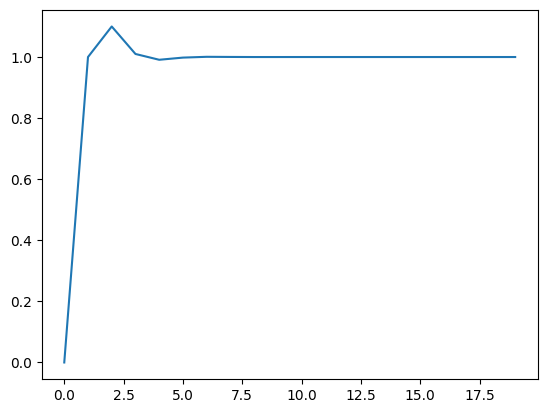

In [6]:
plt.plot(t,y)

In [7]:
import numpy as np
import control as ctrl
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# Define the transfer functions
z = ctrl.TransferFunction.z  # Discrete-time variable

# Function to compute H-infinity norm
def compute_hinfnorm(sys, omega_range):
    mag, _, _ = ctrl.freqresp(sys, omega_range)
    hinf_norm = np.max(np.abs(mag))
    return hinf_norm

# Frequency range for evaluation
omega_range = np.logspace(-2, 2, 500)  # Frequencies from 0.01 to 100 rad/s
G = 1 / ((z - 1))  # One pole near z = 1 and one at z = 1
K = z / (z - 1)  # Controller introduces double integral action

# Function to update the plot based on the value of h
def update_plot(h):
    # Revised transfer functions based on assumptions
    
    H = (1+h) - h * z**-1  # Stable and minimum phase

    # Open-loop transfer function
    # L = G * K

    # Closed-loop transfer functions
    T = ctrl.minreal((G * K) / (1 + G * H * K))  # Closed-loop transfer function
    S = ctrl.minreal(1 / (1 + G * H * K) )        # Sensitivity function

    # Compute H-infinity norms
    T_hinf_norm = compute_hinfnorm(T, omega_range)

    # Get the poles of T and S
    T_poles = T.pole()
    S_poles = S.pole()

    # Combine all poles to determine axis limits
    all_poles = np.concatenate([T_poles, S_poles])
    real_parts = np.real(all_poles)
    imag_parts = np.imag(all_poles)

    # Determine axis limits dynamically
    margin = 0.5  # Add some margin around the poles
    x_min = min(-1.5, np.min(real_parts) - margin)
    x_max = max(1.5, np.max(real_parts) + margin)
    y_min = min(-1.5, np.min(imag_parts) - margin)
    y_max = max(1.5, np.max(imag_parts) + margin)

    # Plot the poles and the unit circle
    plt.figure(figsize=(10, 5))
    
    # Plot the unit circle
    circle = plt.Circle((0, 0), 1, color='green', fill=False, linestyle='--', label='Unit Circle')
    plt.gca().add_patch(circle)
    
    # Plot the poles of T(z) and S(z)
    plt.scatter(np.real(T_poles), np.imag(T_poles), label='Poles of T(z)', marker='x', color='r')
    plt.scatter(np.real(S_poles), np.imag(S_poles), label='Poles of S(z)', marker='o', color='b')
    
    # Add labels, title, and grid
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.title(f'Poles of T(z) and S(z) for h = {h:.2f}\nH-infinity norm of T(z): {T_hinf_norm:.2f}')
    plt.xlabel('Real')
    plt.ylabel('Imaginary')
    plt.legend()
    plt.grid(True)
    
    # Set equal scaling and dynamic limits to ensure all poles are visible
    plt.axis('equal')
    plt.xlim([x_min, x_max])
    plt.ylim([y_min, y_max])
    plt.show()

# Create an interactive slider for h
h_slider = FloatSlider(value=0.4, min=0.1, max=2.0, step=0.1, description='h:')

# Create the interactive plot
interact(update_plot, h=h_slider)

interactive(children=(FloatSlider(value=0.4, description='h:', max=2.0, min=0.1), Output()), _dom_classes=('wi…

<function __main__.update_plot(h)>

In [8]:
ctrl.pole(ctrl.minreal(T))

0 states have been removed from the model


array([0.05+0.3122499j, 0.05-0.3122499j])

In [9]:
ctrl.minreal(L)

0 states have been removed from the model


TransferFunction(array([1., 0.]), array([ 1., -2.,  1.]), True)

In [10]:
G

TransferFunction(array([1]), array([ 1, -1]), True)

In [11]:
ctrl.pole(G)

array([1.+0.j])